In [5]:
import numpy as np

ai_on_real = np.load('./DATA/Mask_Data/set1_ai_on_real_512/masks_npy/000000_mask.npy')
ai_on_real

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)

In [4]:
real_on_fake = np.load('./DATA/Mask_Data/set1_real_on_fake_512/masks_npy/000000_mask.npy')
real_on_fake

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

C:\Windows\Temp\ipykernel_18452\1070923944.py:46: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\1070923944.py:46: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\1070923944.py:46: UserWarning: Glyph 32972 (\N{CJK UNIFIED IDEOGRAPH-80CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\1070923944.py:46: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\1070923944.py:46: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\1070923944.py:46: UserWarning: Glyph 25513 (\N{CJK UNIFIED IDEOGRAPH-63A9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipyker

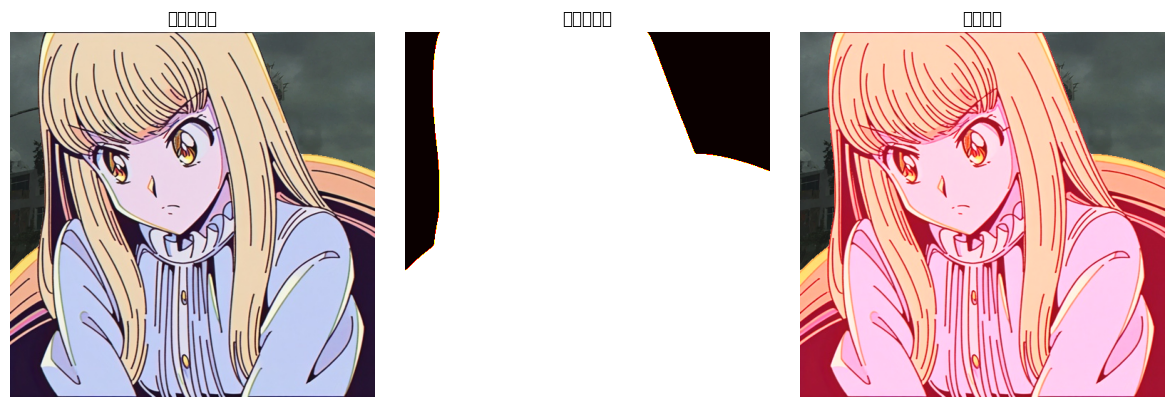

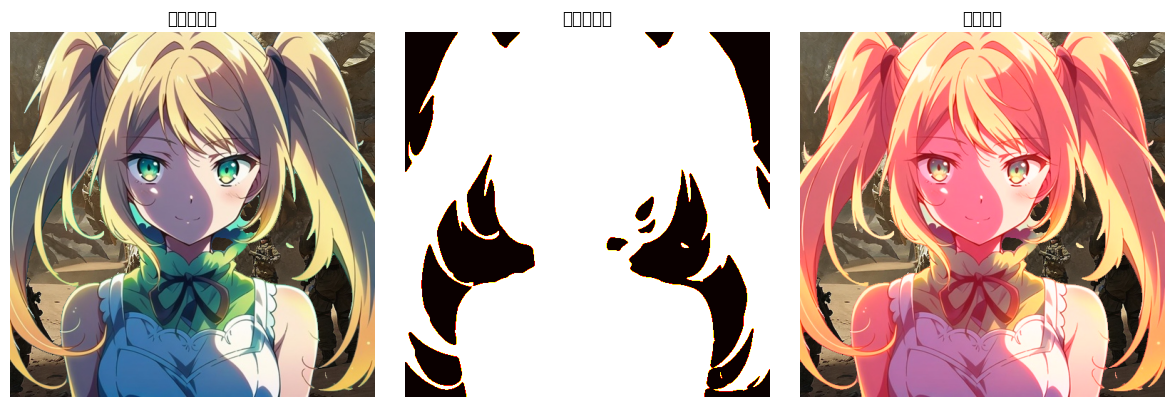

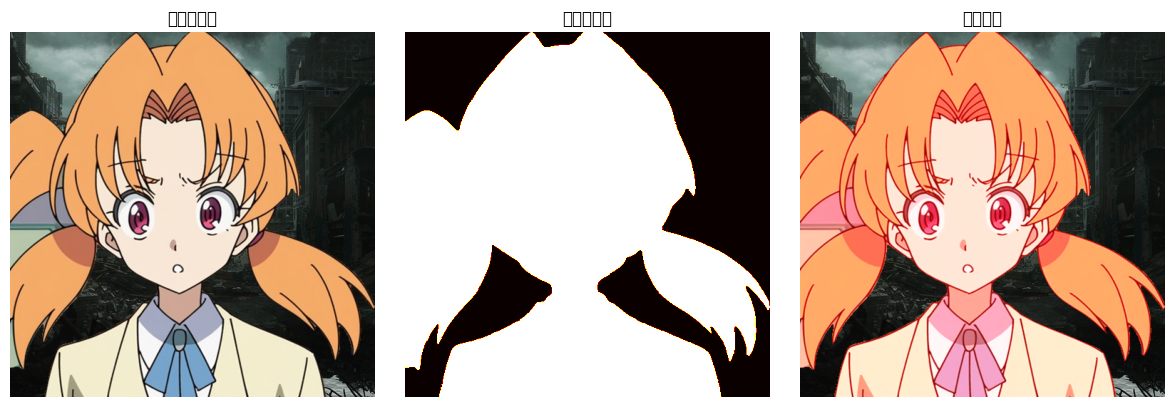

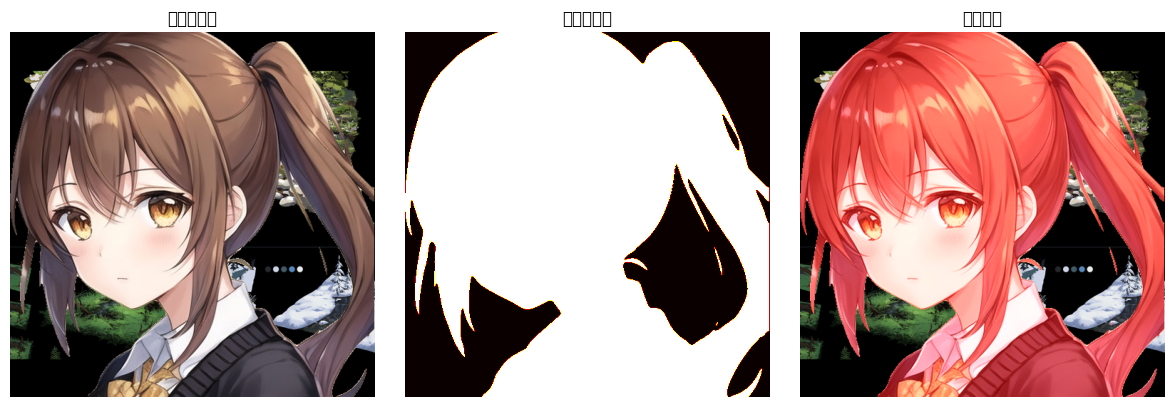

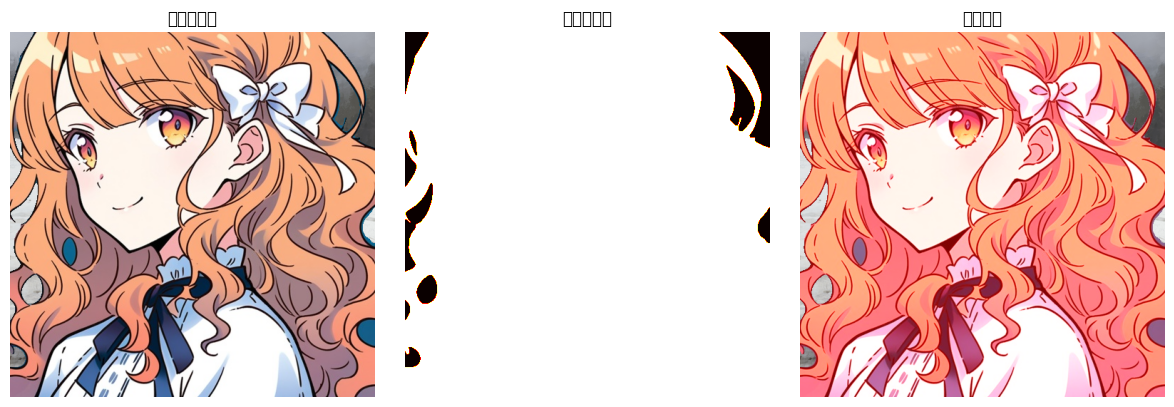

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
for i in range(5):
    # 1. 读取你的npy文件（0和1的掩码）
    mask = np.load(f'./DATA/Mask_Data/set1_ai_on_real_512/masks_npy/00000{i}_mask.npy')

    # 2. 读取你要叠加的背景图片（请替换成你的图片路径）
    background = cv2.imread(f'./DATA/Mask_Data/set1_ai_on_real_512/images/00000{i}.png')
    background = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)  # 转为RGB格式

    # 3. 确保背景和掩码尺寸一致（如果尺寸不同，调整背景大小）
    if background.shape[:2] != mask.shape[:2]:
        background = cv2.resize(background, (mask.shape[1], mask.shape[0]))

    # 4. 创建热力图：将掩码中的1变成彩色（这里用红色热力图）
    # 创建一个和背景同样大小的红色图层
    heatmap = np.zeros_like(background)
    heatmap[:, :, 0] = mask * 255  # 红色通道，掩码为1的地方变成255
    # 你也可以换成其他颜色：
    # heatmap[:, :, 1] = mask * 255  # 绿色通道
    # heatmap[:, :, 2] = mask * 255  # 蓝色通道

    # 5. 叠加图片（透明度混合）
    alpha = 0.5  # 热力图的透明度，0.5表示半透明
    overlay = cv2.addWeighted(background, 1, heatmap, alpha, 0)

    # 6. 显示结果
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(background)
    plt.title('原始背景图')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='hot')  # 用热力图颜色显示掩码
    plt.title('掩码热力图')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title('叠加结果')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

C:\Windows\Temp\ipykernel_18452\4049516312.py:48: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\4049516312.py:48: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\4049516312.py:48: UserWarning: Glyph 32972 (\N{CJK UNIFIED IDEOGRAPH-80CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\4049516312.py:48: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\4049516312.py:48: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_18452\4049516312.py:48: UserWarning: Glyph 25513 (\N{CJK UNIFIED IDEOGRAPH-63A9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipyker

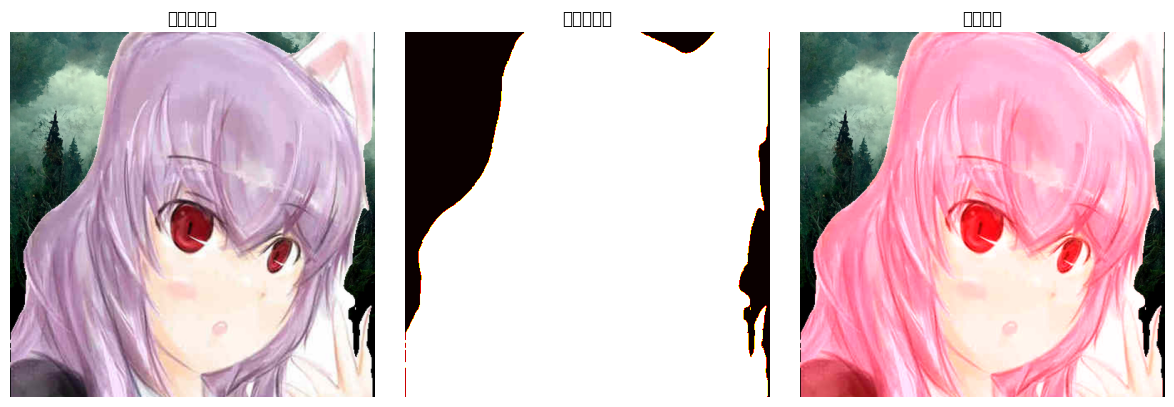

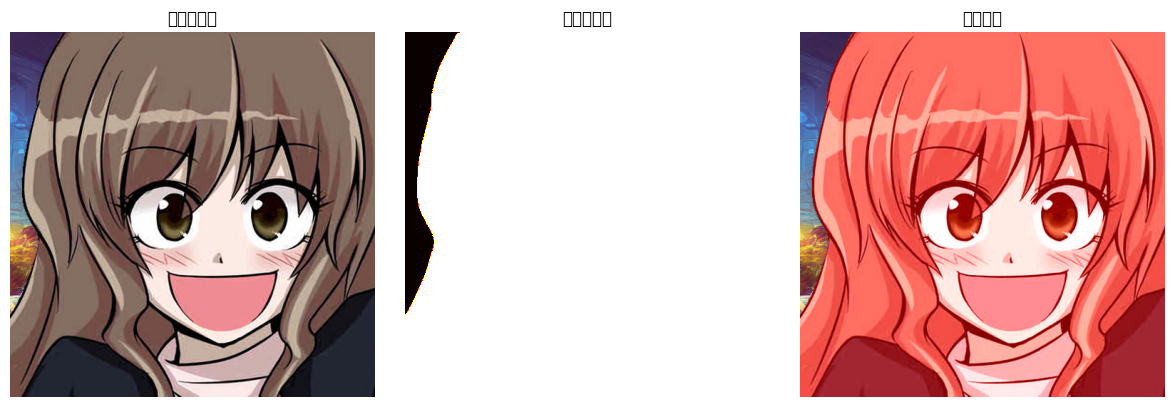

In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
target_item=["000115","000009"]
# for i in range(5):
for i in target_item:
    # 1. 读取你的npy文件（0和1的掩码）
    mask = np.load(f'./DATA/Mask_Data/set1_real_on_fake_512/masks_npy/{i}_mask.npy')

    # 2. 读取你要叠加的背景图片（请替换成你的图片路径）
    background = cv2.imread(f'./DATA/Mask_Data/set1_real_on_fake_512/images/{i}.png')
    background = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)  # 转为RGB格式

    # 3. 确保背景和掩码尺寸一致（如果尺寸不同，调整背景大小）
    if background.shape[:2] != mask.shape[:2]:
        background = cv2.resize(background, (mask.shape[1], mask.shape[0]))

    # 4. 创建热力图：将掩码中的1变成彩色（这里用红色热力图）
    # 创建一个和背景同样大小的红色图层
    heatmap = np.zeros_like(background)
    heatmap[:, :, 0] = mask * 255  # 红色通道，掩码为1的地方变成255
    # 你也可以换成其他颜色：
    # heatmap[:, :, 1] = mask * 255  # 绿色通道
    # heatmap[:, :, 2] = mask * 255  # 蓝色通道

    # 5. 叠加图片（透明度混合）
    alpha = 0.5  # 热力图的透明度，0.5表示半透明
    overlay = cv2.addWeighted(background, 1, heatmap, alpha, 0)

    # 6. 显示结果
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(background)
    plt.title('原始背景图')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='hot')  # 用热力图颜色显示掩码
    plt.title('掩码热力图')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title('叠加结果')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [13]:
import os
import cv2
import numpy as np
import random
from tqdm import tqdm

# =========================
# 配置
# =========================
ROOT = './DATA/Mask_Data'
OUT_ROOT = './dataset_mask'

TRAIN_RATIO = 0.7
VAL_RATIO = 0.1
TEST_RATIO = 0.2

IMG_SIZE = 224
SEED = 42

random.seed(SEED)


# =========================
# 创建目录
# =========================
def make_dirs():
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(OUT_ROOT, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(OUT_ROOT, split, 'masks'), exist_ok=True)


# =========================
# mask语义转换
# =========================
def convert_mask(mask, mode):
    """
    输入：
        mask: 原始mask（0背景，1人像）
        mode:
            ai_on_real
            real_on_fake

    输出：
        新mask：
            0 = Real
            1 = Fake
    """
    if mode == 'ai_on_real':
        # 人像是AI → 1
        new_mask = mask.copy()

    elif mode == 'real_on_fake':
        # 背景是AI → 1
        new_mask = 1 - mask

    else:
        raise ValueError("未知模式")

    return new_mask.astype(np.uint8)


# =========================
# 收集所有数据
# =========================
def collect_samples():
    samples = []

    for folder in os.listdir(ROOT):
        folder_path = os.path.join(ROOT, folder)

        if not os.path.isdir(folder_path):
            print(f"跳过非目录: {folder_path}")
            continue

        # 判断模式
        if 'ai_on_real' in folder:
            mode = 'ai_on_real'
        elif 'real_on_fake' in folder:
            mode = 'real_on_fake'
        else:
            print(f"未知数据类型，跳过: {folder_path}")
            continue

        img_dir = os.path.join(folder_path, 'images')
        mask_dir = os.path.join(folder_path, 'masks_npy')

        if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
            continue

        for fname in os.listdir(img_dir):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img_path = os.path.join(img_dir, fname)

            mask_name = os.path.splitext(fname)[0] + '_mask.npy'
            mask_path = os.path.join(mask_dir, mask_name)

            if not os.path.exists(mask_path):
                continue

            samples.append((img_path, mask_path, mode))

    return samples


# =========================
# 划分数据集
# =========================
def split_dataset(samples):
    random.shuffle(samples)

    total = len(samples)
    n_train = int(total * TRAIN_RATIO)
    n_val = int(total * VAL_RATIO)

    train_samples = samples[:n_train]
    val_samples = samples[n_train:n_train + n_val]
    test_samples = samples[n_train + n_val:]

    return train_samples, val_samples, test_samples


# =========================
# 保存数据
# =========================
def save_samples(samples, split_name):
    img_out_dir = os.path.join(OUT_ROOT, split_name, 'images')
    mask_out_dir = os.path.join(OUT_ROOT, split_name, 'masks')

    counter = {
        'ai_on_real': 0,
        'real_on_fake': 0
    }

    for idx, (img_path, mask_path, mode) in enumerate(tqdm(samples, desc=split_name)):

        # === 1. 读图 ===
        img = cv2.imread(img_path)
        if img is None:
            continue

        # === 2. 读mask ===
        mask = np.load(mask_path)

        # === 3. mask语义转换 ===
        mask = convert_mask(mask, mode)

        # === 4. resize ===
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # === 5. 根据类型编号（🔥关键）
        type_id = counter[mode]
        counter[mode] += 1

        # === 6. 命名（带类型）
        name = f"{split_name}_{mode}_{type_id:06d}"

        img_save_path = os.path.join(img_out_dir, name + '.png')
        mask_save_path = os.path.join(mask_out_dir, name + '.npy')

        # === 7. 保存 ===
        cv2.imwrite(img_save_path, img)
        np.save(mask_save_path, mask)

    print(f"{split_name} 保存完成：")
    print(counter)
    
def count_types(samples):
    cnt = {'ai_on_real':0, 'real_on_fake':0}
    for _, _, mode in samples:
        cnt[mode] += 1
    return cnt

# =========================
# 主流程
# =========================
def main():
    print("📦 创建目录...")
    make_dirs()

    print("📊 收集数据...")
    samples = collect_samples()
    print(f"总样本数: {len(samples)}")

    if len(samples) == 0:
        print("❌ 没有找到数据，请检查路径")
        return

    print("🔀 划分数据集...")
    train_samples, val_samples, test_samples = split_dataset(samples)

    print("\n📊 数据类型分布：")
    print("train:", count_types(train_samples))
    print("val:", count_types(val_samples))
    print("test:", count_types(test_samples))

    print("💾 保存 train...")
    save_samples(train_samples, 'train')

    print("💾 保存 val...")
    save_samples(val_samples, 'val')

    print("💾 保存 test...")
    save_samples(test_samples, 'test')

    print("✅ 数据处理完成！")


if __name__ == "__main__":
    main()

📦 创建目录...
📊 收集数据...
总样本数: 940
🔀 划分数据集...

📊 数据类型分布：
train: {'ai_on_real': 319, 'real_on_fake': 339}
val: {'ai_on_real': 51, 'real_on_fake': 43}
test: {'ai_on_real': 90, 'real_on_fake': 98}
💾 保存 train...


train: 100%|██████████| 658/658 [00:06<00:00, 105.99it/s]


train 保存完成：
{'ai_on_real': 319, 'real_on_fake': 339}
💾 保存 val...


val: 100%|██████████| 94/94 [00:00<00:00, 106.27it/s]


val 保存完成：
{'ai_on_real': 51, 'real_on_fake': 43}
💾 保存 test...


test: 100%|██████████| 188/188 [00:01<00:00, 106.91it/s]

test 保存完成：
{'ai_on_real': 90, 'real_on_fake': 98}
✅ 数据处理完成！
